In [6]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from src.preprocessing import get_features

df_train = pd.read_parquet("data/processed/train.parquet")
X_train = df_train.drop(columns=["target"]).copy()
y_train = df_train["target"].copy()

numeric_features, categorical_features = get_features(df_train)
outlier_features = ["annual_inc", "tot_cur_bal", "revol_bal"]
numeric_features_excluded = [f for f in numeric_features if f not in outlier_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

outlier_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_excluded),
        ("num_log", outlier_transformer, outlier_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=2)),
    ]
)
borrower_pca = pipeline.fit_transform(X_train)


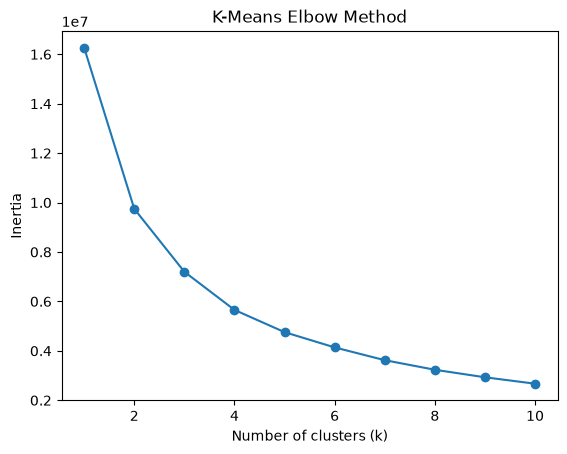

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(borrower_pca)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()

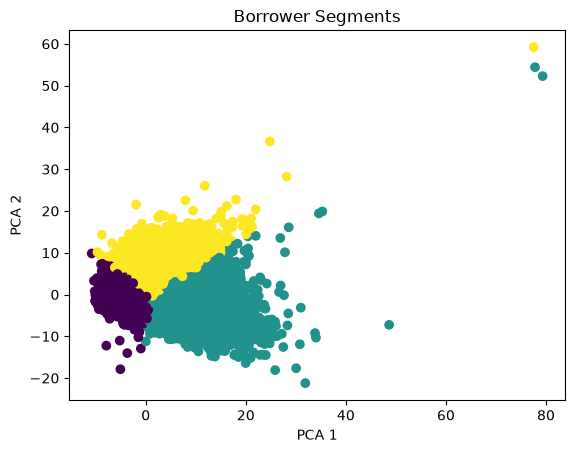

In [3]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(borrower_pca)

plt.scatter(borrower_pca[:, 0], borrower_pca[:, 1], c=labels, cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Borrower Segments")
plt.show()

In [4]:
clusters = (
    pd.DataFrame({"cluster": labels, "default": y_train.values})
    .groupby("cluster")["default"]
    .agg(["mean", "count"])
)

print(clusters)

cluster_1 = X_train[labels == 1].copy()
print(cluster_1.head(5))

cluster_2 = X_train[labels == 2].copy()
print(cluster_2.head(5))

             mean   count
cluster                  
0        0.198136  571132
1        0.228641  213304
2        0.161630  277944
       loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
353       7000.0       7000.0      1842.200000   36 months      7.43   
5678     22000.0      22000.0     21968.613293   36 months     20.86   
13269    12800.0      12800.0     12225.000000   36 months     16.82   
19954    10575.0      10575.0     10550.000000   60 months     21.22   
30389    14500.0      14500.0     14475.000000   60 months     23.59   

       installment grade sub_grade                                 emp_title  \
353         217.52     A        A2                                   Retired   
5678        827.33     G        G4  Lake County High Schools Technology Camp   
13269       455.21     E        E2                        The Bank of Harlan   
19954       287.40     G        G4                                      FDIC   
30389       413.70     G        G5   

# Understanding Week 8

## PCA + K-Means Segmentation

Ran PCA down to 2 components on the same preprocessed feature space as week 7, then k-means on top of that. annual_inc and revol_bal are extremely skewed (skew ~46 and ~15). Raw StandardScaler let a handful of $1M+ earners dominate both components and stretch the plot into a few outlier points instead of a readable shape. Log1p'd those two, plus tot_cur_bal, before scaling. Fixed it.

Picked k=3 off an elbow plot. The bend isn't sharp. Inertia keeps dropping steadily past k=3 instead of flattening hard, so this is more a judgment call than a clean answer.

| Cluster | Size | Default rate | Loan amt | Income | DTI  | FICO |
| ------- | ---- | ------------ | -------- | ------ | ---- | ---- |
| 0       | 571k | 19.8%        | $9.6k    | $50k   | 16.5 | 680  |
| 1       | 213k | 22.9%        | $16k     | $75k   | 21.2 | 690  |
| 2       | 278k | 16.2%        | $21k     | $90k   | 17.1 | 700  |

Cluster 0 is small-loan, lower-income, mostly 36-month. Sits almost exactly at the ~19.5% base rate. Clusters 1 and 2 both got pulled out as "bigger loan, longer term" but split from each other on debt burden, not loan size. Cluster 2's loans are actually the biggest of the three, but higher income and lower DTI put its default rate 3.3pp below base. Cluster 1 carries the worst DTI of the three (21.2) despite getting charged the same rate as cluster 0 (12.99%). The rate isn't pricing that risk in.


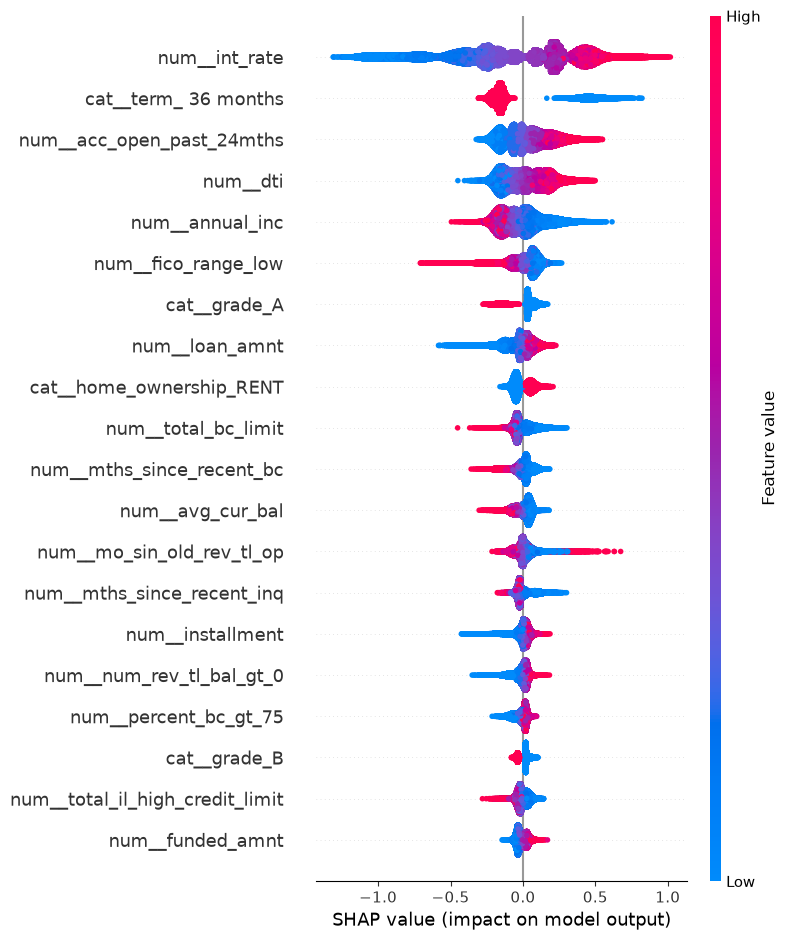

(265595, 196)


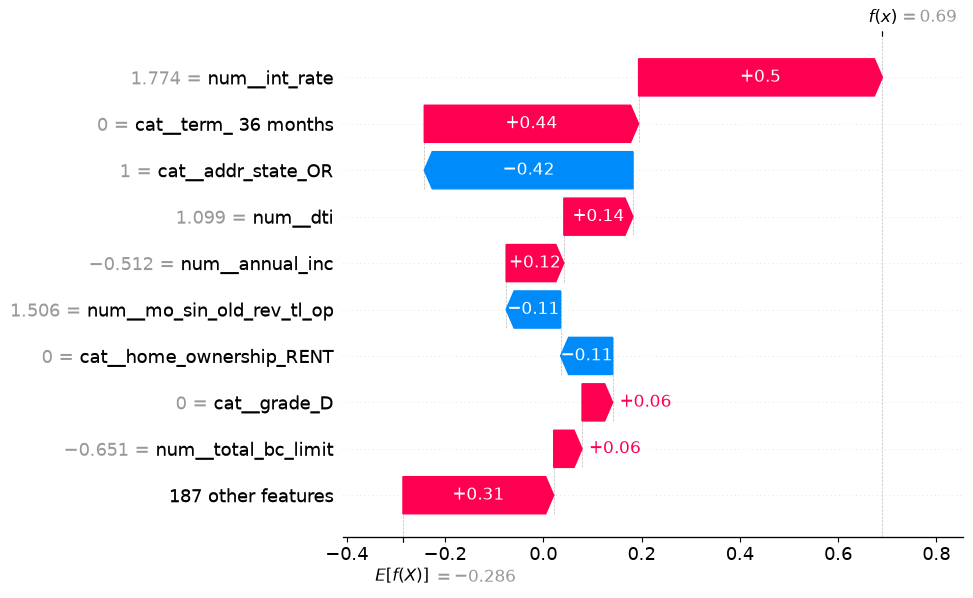

In [ ]:
import shap
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                is_unbalance=True,
                random_state=42,
                verbose=-1,
                n_jobs=-1,
                learning_rate=0.0562,
                max_depth=9,
                n_estimators=363,
                num_leaves=61,
            ),
        ),
    ],
)

tscv = TimeSeriesSplit(n_splits=3)

train_idx, test_idx = list(tscv.split(X_train))[-1]


lgbm_pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

trained_model = lgbm_pipeline.named_steps["classifier"]

feature_names = lgbm_pipeline.named_steps["preprocessor"].get_feature_names_out()

X_test_transformed = lgbm_pipeline.named_steps["preprocessor"].transform(
    X_train.iloc[test_idx]
)

# Convert to DataFrame so SHAP plots display proper feature names
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# TreeExplainer calculates exact Shapley values optimized for tree models
explainer = shap.TreeExplainer(trained_model)
shap_values = explainer(X_test_df)

# Visualize the results
shap.summary_plot(shap_values, X_test_df)

shap.plots.waterfall(shap_values[0])

## SHAP

SHAP analysis shows which features are most used to make predictions. We used SHAP with `TreeExplainer` on the winning LGBM from week 7. The model was fit on the last fold of the `TimeSeriesSplit` so that we do not use the test data until week 9. All values in the plots are the normalized values.

We found that these features tipped the summary plot:

- `num__int_rate`
- `cat__term_ 36 months`
- `num__acc_open_past_24mths`
- `num__dti`
- `num__annual_inc`
- `num__fico_range_low`

All features are in the direction of domain knowledge. Higher interest rates lead to to defaults, etc.

In the waterfall diagram we see what features affect a potential borrower's for defaulting. Interest rate is the biggest factor for default, as well as the 36 months terms. An interesting decrease in default probability for borrowers in Oregon. There are 12974 loans (~1.2%) issued in Oregon which is a significant.

SHAP's TreeExplainer output here is in raw margin (log-odds) space, not probability. f(x) = 0.69 for the example borrower and E[f(X)] = -0.286 for the baseline aren't percentages until you run them through a sigmoid. Doing that: sigmoid(-0.286) ≈ 0.43, sigmoid(0.69) ≈ 0.67. The baseline alone lands at 43%, more than double the true ~19.5% default rate in the data.

That's the same distortion week 7 already flagged: is_unbalance=True rescales the probability axis during training, so the model's outputs were never calibrated probabilities to begin with. Week 7 caught this in the Brier scores (LightGBM: 0.2004) and the calibration curve, where a predicted 90% corresponded to a real rate of 67-79%. What SHAP adds is that the distortion is not confined to the final prediction. It is baked into the baseline expectation and the entire log-odds space the explainer works in.

Practically, that means the SHAP values in these plots (int_rate contributing +0.5, term contributing +0.44, etc.) are trustworthy for ranking which features matter most relative to each other, but the magnitudes shouldn't be read as literal percentage-point contributions to true default risk. The same rescaling that inflated week 7's predicted probabilities inflates these numbers too.


In [18]:
from scipy.stats import norm

or_mask = X_train["addr_state"] == "OR"

or_defaults = y_train[or_mask].sum()
or_count = or_mask.sum()
or_rate = or_defaults / or_count

rest_defaults = y_train[~or_mask].sum()
rest_count = (~or_mask).sum()
rest_rate = rest_defaults / rest_count

pooled_rate = (or_defaults + rest_defaults) / (or_count + rest_count)
se = np.sqrt(pooled_rate * (1 - pooled_rate) * (1 / or_count + 1 / rest_count))
z_stat = (or_rate - rest_rate) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"Oregon default rate: {or_rate:.4f} ({or_count:,} loans)")
print(f"Rest of US default rate: {rest_rate:.4f} ({rest_count:,} loans)")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")


Oregon default rate: 0.1437 (12,974 loans)
Rest of US default rate: 0.1953 (1,049,406 loans)
z-statistic: -14.7716
p-value: 0.000000
